In [176]:
import warnings

warnings.filterwarnings("ignore")

from itertools import groupby

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import scipy.stats as stats
from scipy.stats import spearmanr
from scipy.stats import shapiro

import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_score, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold

import textwrap

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 11
pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

### 1. Получить файл варианта с данными

In [177]:
DATA_PATH = "Вар_42_Б24-215_Гаганидзе_Лаба2_студент.xlsx"
#DATA_PATH = "Вар_46_Б24-215_Кузьмина_Лаба2_студент.xlsx"
df_raw = pd.read_excel(DATA_PATH)
print(f"Размер: {df_raw.shape}")
# print(f"Колонки:\n {"\n".join(list(df_raw.columns))}")
display(df_raw)

Размер: (2500, 26)


,ID,"Среднегодовой доход, тыс. $","Объем потребленного алкоголя в год, л.",Количество членов семьи,Количество лет образования,"Доля от дохода семьи которая тратится на продовольствие, %",Коэффициент Джини сообщества,"Издержки сообщества на окружающую среду, млн. $","Охват беспроводной связи в сообществе, %","Количество смертей от вирусных и респираторных заболеваний в сообществе, тыс. человек",Волатильность потребительских цен в сообществе,Сфера занятости,Оценка благополучия,Оценка социальной поддержки,Ожидаемая продолжительность здоровой жизни,Свобода граждан самостоятельно принимать жизненно важные решения,Индекс Щедрости,Индекс отношения к коррупции,Оценка риска безработицы,Индекс кредитного оптимизма,Индекс страха социальных конфликтов,Индекс семьи,Индекс продовольственной безопасности,Чувство технологического прогресса,Чувство неравенства доходов в обществе,Ощущаемое счастье
0,1,42.755,0.00,4,9,51.0,0.785364,0.00,0.521,8.92,0.00,Государственная служба,45.0,38.0,49.0,45.0,62.0,58.0,56.0,51.0,25.0,79.0,39.0,44.0,58.0,Coping
1,2,38.226,4.64,8,9,49.9,0.774636,0.00,0.566,29.60,0.24,МСП,52.0,53.0,68.0,58.0,39.0,63.0,50.0,46.0,43.0,87.0,26.0,43.0,55.0,Suffering
2,3,17.772,8.80,5,9,58.7,0.785364,0.00,0.521,8.92,0.00,МСП,30.0,59.0,55.0,42.0,36.0,84.0,63.0,45.0,52.0,72.0,52.0,34.0,52.0,Suffering
3,4,131.255,1.76,5,9,41.5,0.662150,164.23,0.651,19.10,1.89,Самозанятый,66.0,56.0,41.0,76.0,62.0,54.0,58.0,44.0,63.0,71.0,58.0,58.0,46.0,Just ok
4,5,73.784,3.65,4,9,48.5,0.318281,284.26,0.169,21.34,4.89,МСП,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Неизвестно
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2495,2496,34.460,11.44,4,10,63.6,0.420601,183.06,0.444,35.00,5.24,Государственная служба,54.0,39.0,69.0,65.0,40.0,54.0,58.0,30.0,56.0,33.0,15.0,43.0,51.0,Depressed
2496,2497,187.537,14.79,4,11,38.7,0.333281,206.04,0.619,0.00,4.74,Государственная служба,36.0,59.0,62.0,53.0,32.0,26.0,57.0,49.0,31.0,51.0,22.0,60.0,69.0,Doing well
2497,2498,305.668,0.00,8,10,36.4,0.774636,0.00,0.566,29.60,0.24,Самозанятый,66.0,25.0,64.0,44.0,57.0,48.0,63.0,56.0,58.0,100.0,28.0,69.0,88.0,Just ok
2498,2499,159.398,1.95,4,11,42.7,0.662150,164.23,0.651,19.10,1.89,Самозанятый,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Неизвестно


In [178]:
df_work = df_raw.drop(columns=["ID"])

grouped_data = [
    (is_numeric, df_work[list(g)])
    for is_numeric, g in groupby(
        df_work.columns, key=lambda c: df_work[c].dtype != "str"
    )
]

for i, (is_numeric, df_group) in enumerate(grouped_data, 1):
    group_type = "Численные" if is_numeric else "Строковые"
    print(f"--- Группа {i} ({group_type}) ---")
    print(*df_group.columns, sep="\n", end="\n\n")

--- Группа 1 (Численные) ---
Среднегодовой доход, тыс. $
Объем потребленного алкоголя в год, л.
Количество членов семьи
Количество лет образования
Доля от дохода семьи которая тратится на продовольствие, %
Коэффициент Джини сообщества
Издержки сообщества на окружающую среду, млн. $
Охват беспроводной связи в сообществе, %
Количество смертей от вирусных и респираторных заболеваний в сообществе, тыс. человек
Волатильность потребительских цен в сообществе

--- Группа 2 (Строковые) ---
Сфера занятости

--- Группа 3 (Численные) ---
Оценка благополучия
Оценка социальной поддержки
Ожидаемая продолжительность здоровой жизни
Свобода граждан самостоятельно принимать жизненно важные решения
Индекс Щедрости
Индекс отношения к коррупции
Оценка риска безработицы
Индекс кредитного оптимизма
Индекс страха социальных конфликтов
Индекс семьи
Индекс продовольственной безопасности
Чувство технологического прогресса
Чувство неравенства доходов в обществе

--- Группа 4 (Строковые) ---
Ощущаемое счастье



### 2. Открыть набор данных и выделить группы признаков: причины, состояния, целевая переменная

In [179]:
# Полный ординальный порядок меток (от худшего к лучшему).
# 'Strugglng' — опечатка в исходных данных, оставляем как есть.
CANTRIL_ORDER = [
    "Hopeless",
    "Depressed",
    "Suffering",
    "Strugglng",
    "Coping",
    "Just ok",
    "Doing well",
    "Blooming",
    "Thriving",
    "Prospering",
]

CANTRIL_COL = df_raw.columns[-1]  # "Ощущаемое счастье"
MARKER_UNKNOWN = "Неизвестно"  # метка «неизвестно» в этой колонке

ALL_CAUSE, STATE_FEATURES = [
    list(g.columns) for is_numeric, g in grouped_data if is_numeric
]

print(ALL_CAUSE)

CAT_FEATURES = [
    col for is_numeric, g in grouped_data
    if not is_numeric and CANTRIL_COL not in g.columns
    for col in g.columns
]
print(CAT_FEATURES)

SIGNIFICANCE_THRESHOLD = 0.08  # порог |ρ| для отбора признаков состояния
VIF_THRESHOLD = 10.0
PVALUE_THRESHOLD = 0.05
RHO_THRESHOLD = 0.3

['Среднегодовой доход, тыс. $', 'Объем потребленного алкоголя в год, л.', 'Количество членов семьи', 'Количество лет образования', 'Доля от дохода семьи которая тратится на продовольствие, %', 'Коэффициент Джини сообщества', 'Издержки сообщества на окружающую среду, млн. $', 'Охват беспроводной связи в сообществе, %', 'Количество смертей от вирусных и респираторных заболеваний в сообществе, тыс. человек', 'Волатильность потребительских цен в сообществе']
['Сфера занятости']


### 3. Выделить наблюдения с известным и неизвестным значением счастья

In [180]:
is_unknown = (df_raw[CANTRIL_COL].str.strip() == MARKER_UNKNOWN) | \
    (df_raw[CANTRIL_COL].isna())

df_known = df_raw[~is_unknown].copy()
df_unknown = df_raw[is_unknown].copy()

print(f"Известных записей:   {len(df_known)}")
print(f"Неизвестных записей: {len(df_unknown)}")

actual_classes = [
    c for c in CANTRIL_ORDER if c in df_known[CANTRIL_COL].unique()
]
df_known["rank"] = pd.Categorical(
    df_known[CANTRIL_COL], categories=actual_classes, ordered=True
).codes

print("Кодировка классов:")
for rank, cls in enumerate(actual_classes):
    print(f"  {rank:>2}: {cls}")

Известных записей:   1900
Неизвестных записей: 600
Кодировка классов:
   0: Hopeless
   1: Depressed
   2: Suffering
   3: Strugglng
   4: Coping
   5: Just ok
   6: Doing well
   7: Blooming
   8: Thriving
   9: Prospering


### 4. Провести первичный анализ данных (описательные статистики, визуализация, проверка пропусков)


Пропусков в неизвестных данных:
Оценка благополучия                                                 600
Оценка социальной поддержки                                         600
Ожидаемая продолжительность здоровой жизни                          600
Свобода граждан самостоятельно принимать жизненно важные решения    600
Индекс Щедрости                                                     600
Индекс отношения к коррупции                                        600
Оценка риска безработицы                                            600
Индекс кредитного оптимизма                                         600
Индекс страха социальных конфликтов                                 600
Индекс семьи                                                        600
Индекс продовольственной безопасности                               600
Чувство технологического прогресса                                  600
Чувство неравенства доходов в обществе                              600
dtype: int64


Описательные чис

,count,mean,std,min,25%,50%,75%,max
ID,2500.0,1250.50,721.83,1.00,625.75,1250.50,1875.25,2500.00
"Среднегодовой доход, тыс. $",2500.0,159.87,137.28,2.87,72.57,128.51,208.16,1622.02
"Объем потребленного алкоголя в год, л.",2500.0,8.05,8.77,0.00,1.41,5.98,11.30,45.00
Количество членов семьи,2500.0,4.44,1.20,1.00,4.00,4.00,5.00,9.00
Количество лет образования,2500.0,10.27,2.64,3.00,9.00,10.00,12.00,18.00
"Доля от дохода семьи которая тратится на продовольствие, %",2500.0,46.10,10.97,19.60,37.40,45.40,53.62,74.20
Коэффициент Джини сообщества,2500.0,0.47,0.16,0.26,0.32,0.42,0.63,0.79
"Издержки сообщества на окружающую среду, млн. $",2500.0,203.56,85.65,0.00,164.23,206.04,266.19,396.33
"Охват беспроводной связи в сообществе, %",2500.0,0.53,0.23,0.10,0.36,0.53,0.65,0.95
"Количество смертей от вирусных и респираторных заболеваний в сообществе, тыс. человек",2500.0,18.36,10.05,0.00,11.18,19.10,28.51,35.00


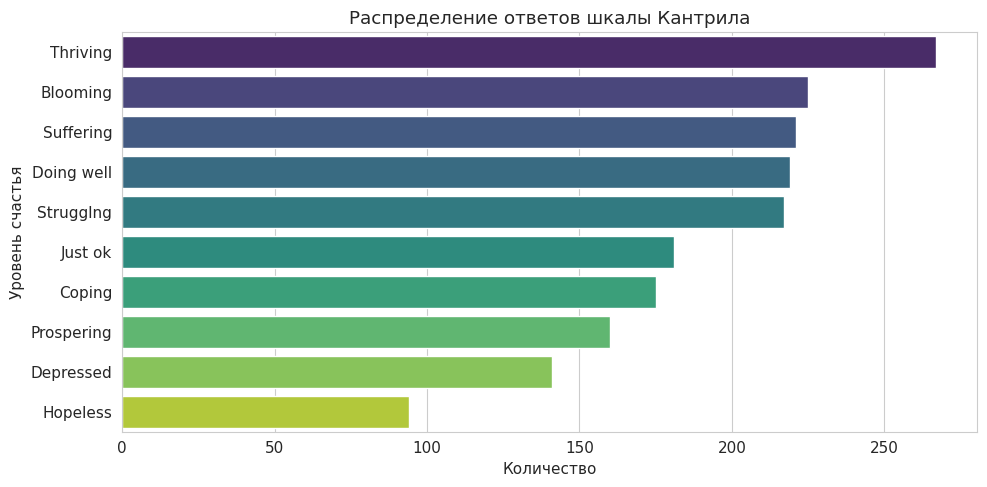

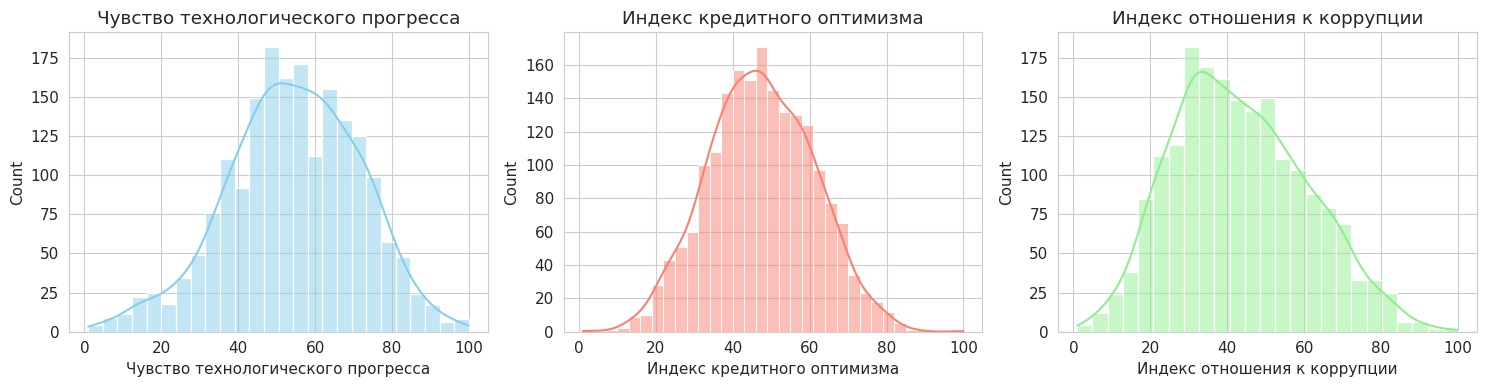

In [181]:
# 1. Проверка пропусков
print("\nПропусков в неизвестных данных:")
missing_info = df_raw.isna().sum()
missing_info = missing_info[missing_info > 0]
if missing_info.empty:
    print("Пропусков нет!\n")
else:
    print(missing_info)
    print("\n")

# 2. Описательные статистики числовых признаков
print("Описательные числовые статистики:")
display(df_raw.describe().round(2).T)

# 3. Визуализация распределения целевой переменной
plt.figure(figsize=(10, 5))
sns.countplot(
    data=df_known,
    y=CANTRIL_COL,
    order=df_known[CANTRIL_COL].value_counts().index,
    palette="viridis",
)
plt.title("Распределение ответов шкалы Кантрила")
plt.xlabel("Количество")
plt.ylabel("Уровень счастья")
plt.tight_layout()
plt.show()

# 5. Визуализация некоторых числовых признаков (гистограммы состояния)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(
    df_raw["Чувство технологического прогресса"],
    kde=True,
    ax=axes[0],
    color="skyblue",
)
axes[0].set_title("Чувство технологического прогресса")

sns.histplot(
    df_raw["Индекс кредитного оптимизма"], kde=True, ax=axes[1], color="salmon"
)
axes[1].set_title("Индекс кредитного оптимизма")

sns.histplot(
    df_raw["Индекс отношения к коррупции"],
    kde=True,
    ax=axes[2],
    color="lightgreen",
)
axes[2].set_title("Индекс отношения к коррупции")

plt.tight_layout()
plt.show()

### 5. Исследовать влияние признаков причины на признаки состояния (корреляционный анализ, линейные регрессии)

Список анализируемых причин: ['Среднегодовой доход, тыс. $', 'Объем потребленного алкоголя в год, л.', 'Количество членов семьи', 'Количество лет образования', 'Доля от дохода семьи которая тратится на продовольствие, %', 'Коэффициент Джини сообщества', 'Издержки сообщества на окружающую среду, млн. $', 'Охват беспроводной связи в сообществе, %', 'Количество смертей от вирусных и респираторных заболеваний в сообществе, тыс. человек', 'Волатильность потребительских цен в сообществе']


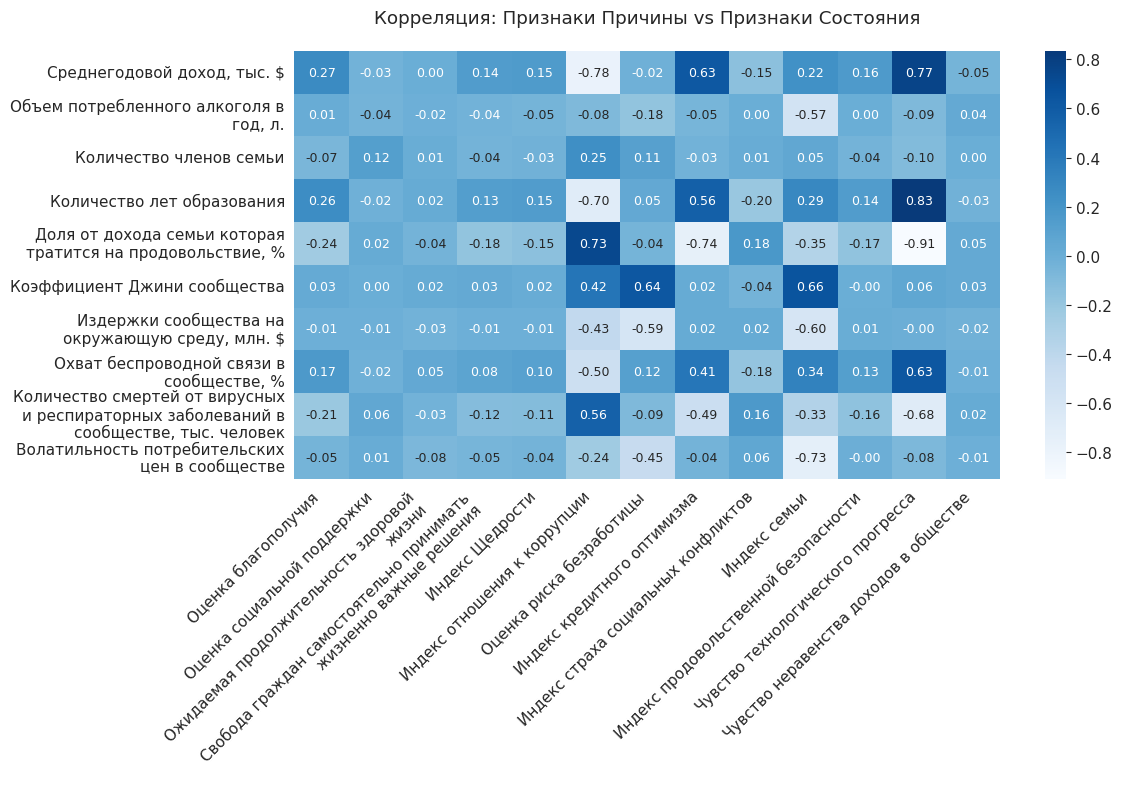

In [182]:
plt.figure(figsize=(12, 8))

# Используем list(), чтобы сложение списков прошло корректно
all_analysis_cols = list(ALL_CAUSE) + list(STATE_FEATURES)

cause_state_corr = (
    df_known[all_analysis_cols]
    .corr(method="spearman")
    .loc[ALL_CAUSE, STATE_FEATURES]
)

# Вывод колонок теперь в отдельной строке
print("Список анализируемых причин:", ALL_CAUSE)

wrapped_y_labels = [textwrap.fill(label, 30) for label in cause_state_corr.index]
wrapped_x_labels = [textwrap.fill(label, 40) for label in cause_state_corr.columns]

sns.heatmap(
    cause_state_corr,
    cmap="Blues",
    center=0,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 9},
    yticklabels=wrapped_y_labels,
    xticklabels=wrapped_x_labels,
)
plt.title("Корреляция: Признаки Причины vs Признаки Состояния", pad=20)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [183]:
# 1. Сначала разбиение
X = df_known[list(ALL_CAUSE) + list(STATE_FEATURES)]
y = df_known[CANTRIL_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

cause_cols = ALL_CAUSE.copy()
print(cause_cols)

# 2. Функция VIF только для тренировочных данных
def compute_vif_train(X_df):
    X_const = sm.add_constant(X_df.dropna())
    vif_vals = [variance_inflation_factor(X_const.values, i) for i in range(1, X_const.shape[1])]
    return pd.DataFrame({"Признак": X_df.columns, "VIF": vif_vals}).sort_values("VIF", ascending=False)

current_cols = list(X_train.columns)
while True:
    vif_res = compute_vif_train(X_train[current_cols])
    worst = vif_res.iloc[0]
    if worst["VIF"] <= VIF_THRESHOLD:
        break
    current_cols.remove(worst["Признак"])

print("Итоговые колонки после VIF:", *current_cols, sep="\n", end="\n\n")

# Тренируем отдельную модель для каждого "Состояния" на основе отобранных "Причин"
# (полный датасет df_known, это описательная часть шага 5)
ols_state_models_full = {}

for state_col in STATE_FEATURES:
    # 1. Подготавливаем данные: выбрасываем строки с NaN для текущей пары
    valid_data = df_known.dropna(subset=[state_col] + list(cause_cols))
    if valid_data.empty:
        continue

    y_target = valid_data[state_col]
    X_features = sm.add_constant(
        valid_data[cause_cols]
    )  # Добавляем константу (b_0)

    # 2. ТРЕНИРУЕМ МОДЕЛЬ (вызов .fit())
    model = sm.OLS(y_target, X_features).fit()
    ols_state_models_full[state_col] = model

    # Значимость влияния в OLS оценивается по t-stat (или p-value), а сила - по размеру коэффициента.
    # Чтобы сравнить признаки между собой, посмотрим на абсолютные значения t-статистики (tvalues)
    # Исключаем константу 'const' из топа
    t_stats = model.tvalues.drop("const").abs()

    print(f"\nВлияющие причины на состояние '{state_col}':")

    # Чтобы считать стандартизованный коэффициент, нам нужны стандартные отклонения
    std_y = y_target.std()
    std_X = X_features.std()

    for cause_name, t_val in t_stats.items():
        # Достаем сам коэффициент (положительный он или отрицательный) и p-value
        coef = model.params[cause_name]
        p_val = model.pvalues[cause_name]

        # Считаем стандартизованный коэффициент (Beta) для оценки РЕАЛЬНОЙ силы влияния
        beta_coef = coef * (std_X[cause_name] / std_y)

        # Выводим ТОЛЬКО те признаки, у которых:
        # 1. p-value < 0.05 (статистическая значимость)
        # 2. |Beta| >= 0.1 (практическая значимость, отсекаем микро-влияния)
        if p_val < PVALUE_THRESHOLD and abs(beta_coef) >= 0.1:
            print(f"    • {cause_name}")
            print(
                f"      Влияние: {'прямое' if coef > 0 else 'обратное'} (p={p_val:.4f}, Beta={beta_coef:+.3f})"
            )

['Среднегодовой доход, тыс. $', 'Объем потребленного алкоголя в год, л.', 'Количество членов семьи', 'Количество лет образования', 'Доля от дохода семьи которая тратится на продовольствие, %', 'Коэффициент Джини сообщества', 'Издержки сообщества на окружающую среду, млн. $', 'Охват беспроводной связи в сообществе, %', 'Количество смертей от вирусных и респираторных заболеваний в сообществе, тыс. человек', 'Волатильность потребительских цен в сообществе']
Итоговые колонки после VIF:
Среднегодовой доход, тыс. $
Объем потребленного алкоголя в год, л.
Количество членов семьи
Количество лет образования
Доля от дохода семьи которая тратится на продовольствие, %
Издержки сообщества на окружающую среду, млн. $
Охват беспроводной связи в сообществе, %
Количество смертей от вирусных и респираторных заболеваний в сообществе, тыс. человек
Волатильность потребительских цен в сообществе
Оценка благополучия
Оценка социальной поддержки
Ожидаемая продолжительность здоровой жизни
Свобода граждан самосто

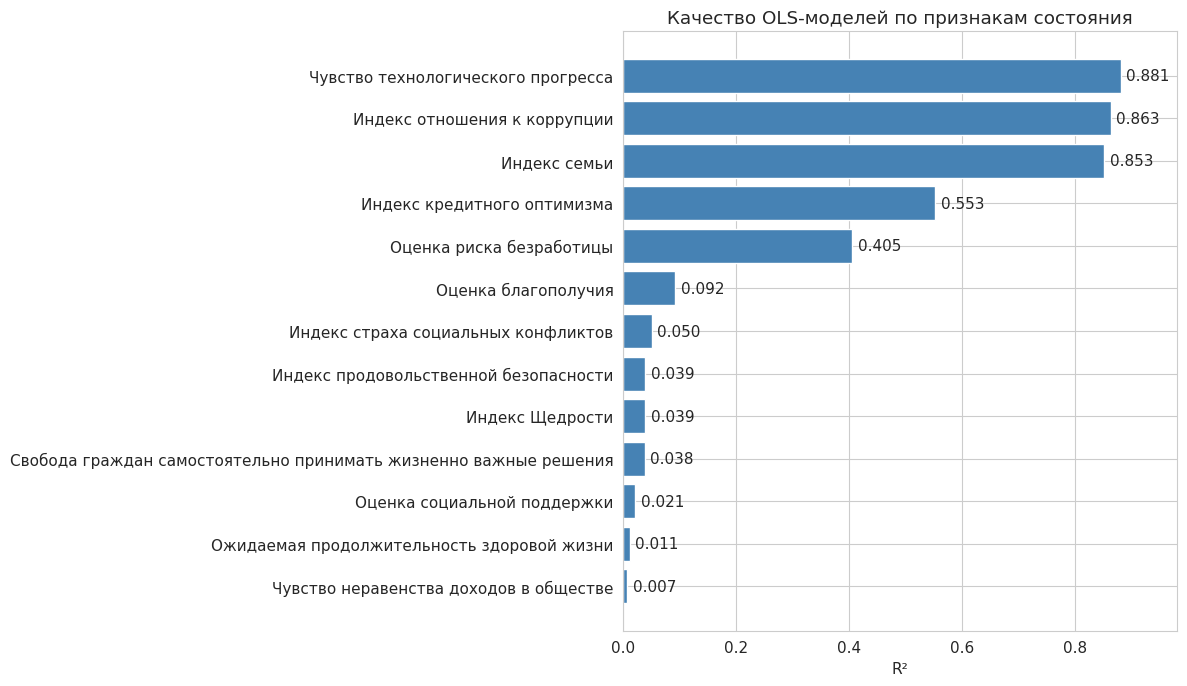

In [184]:
rsquared_df = pd.DataFrame(
    {
        "Признак состояния": [
            s for s in STATE_FEATURES if s in ols_state_models_full
        ],
        "R²": [
            ols_state_models_full[s].rsquared
            for s in STATE_FEATURES
            if s in ols_state_models_full
        ],
    }
).sort_values("R²", ascending=True)

plt.figure(figsize=(12, 7))
bars = plt.barh(
    rsquared_df["Признак состояния"], rsquared_df["R²"], color="steelblue"
)
plt.xlabel("R²")
plt.title("Качество OLS-моделей по признакам состояния")

for bar, val in zip(bars, rsquared_df["R²"]):
    plt.text(
        val + 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.3f}",
        va="center",
    )

plt.xlim(0, max(rsquared_df["R²"]) + 0.1)
plt.tight_layout()
plt.show()

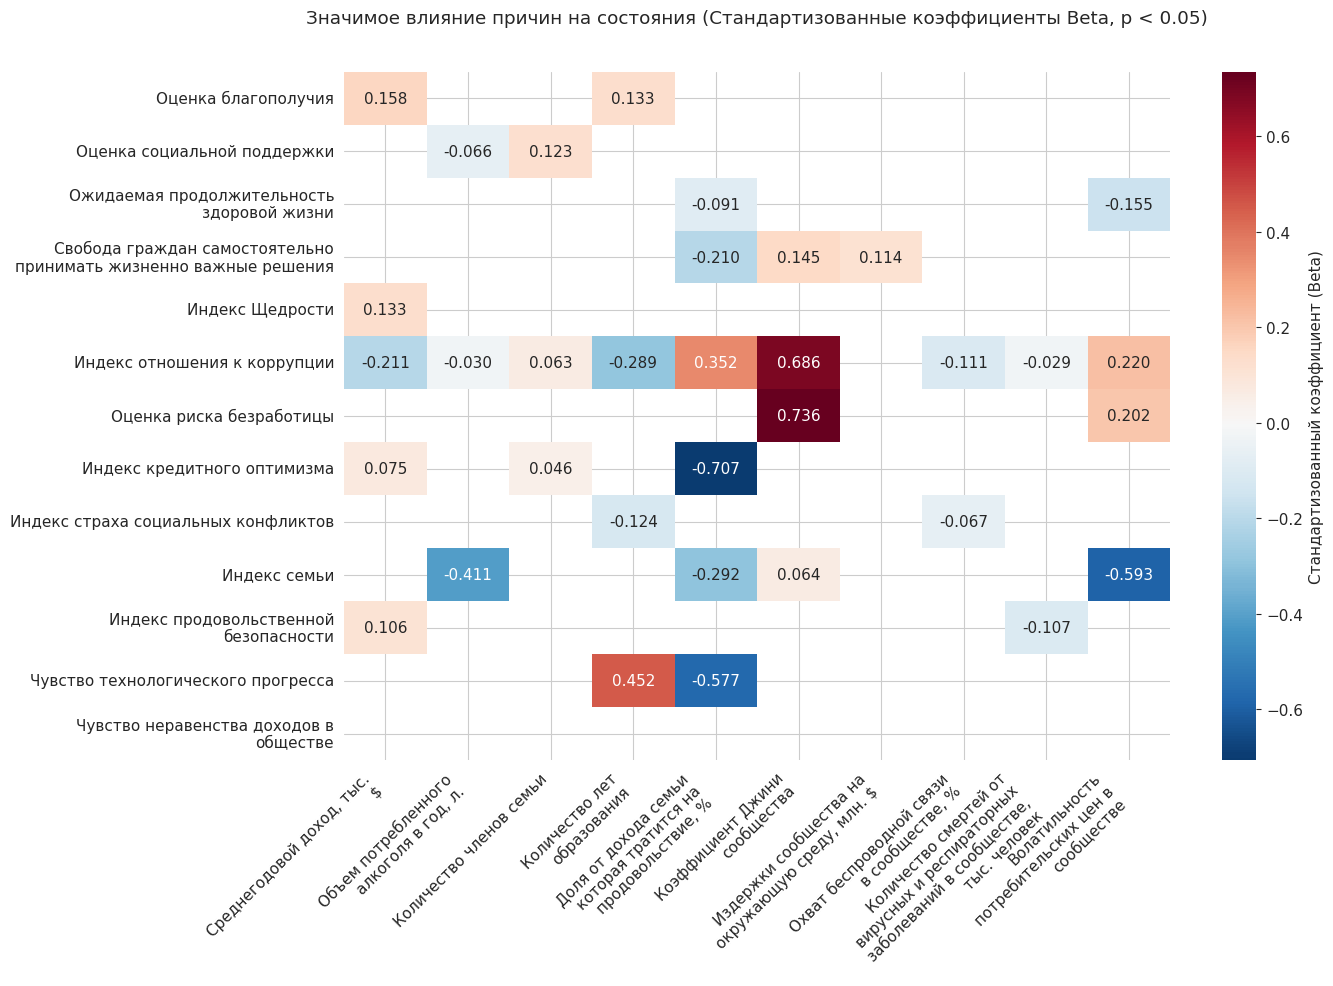

In [185]:
p_val_matrix = pd.DataFrame()
coef_matrix = pd.DataFrame()

for state, model in ols_state_models_full.items():
    p_val_matrix[state] = model.pvalues.drop("const")

    # Считаем СТАНДАРТИЗОВАННЫЕ коэффициенты (Beta)
    # Формула: Beta = b * (std(X) / std(Y))
    valid_data = df_known.dropna(subset=[state] + cause_cols)
    std_x = valid_data[cause_cols].std()
    std_y = valid_data[state].std()

    std_coefs = model.params.drop("const") * (std_x / std_y)
    coef_matrix[state] = std_coefs

# Транспонируем (состояния - строки, причины - столбцы)
p_val_matrix = p_val_matrix.T
coef_matrix = coef_matrix.T

# Создаем матрицу-маску: оставляем коэффициенты ТОЛЬКО там, где p < 0.05
significant_coefs = coef_matrix.mask(p_val_matrix >= PVALUE_THRESHOLD)

plt.figure(figsize=(14, 10))
# cmap='RdBu_r' - красные (положительные), синие (отрицательные)
sns.heatmap(
    significant_coefs,
    cmap="RdBu_r",
    center=0,
    annot=True,
    fmt=".3f",
    xticklabels=[textwrap.fill(c, 25) for c in significant_coefs.columns],
    yticklabels=[textwrap.fill(c, 35) for c in significant_coefs.index],
    cbar_kws={"label": "Стандартизованный коэффициент (Beta)"},
)

plt.title(
    "Значимое влияние причин на состояния (Стандартизованные коэффициенты Beta, p < 0.05)\n",
    pad=20,
)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### 6. Проверить влияние категориальных факторов на признаки состояния (например, сфера занятости; ANOVA, тест Манна—Уитни)

In [186]:
for cat_feature in CAT_FEATURES:
    groups = df_known[cat_feature].dropna().unique()
    print(
        f"Влияние категориального фактора '{cat_feature}' на признаки состояния\n"
    )

    for state_col in STATE_FEATURES:
        # Собираем значения признака состояния для каждой отдельной категории
        group_data = [
            df_known[df_known[cat_feature] == g][state_col].dropna()
            for g in groups
        ]

        # Отфильтруем группы, в которых слишком мало наблюдений (например, < 5)
        group_data = [d for d in group_data if len(d) >= 5]

        if len(group_data) == 2:
            # Если ровно 2 гectруппы (например, Мужчины / Женщины) -> Тест Манна-Уитни
            stat, p_val = stats.mannwhitneyu(
                group_data[0], group_data[1], alternative="two-sided"
            )
            test_name = "Манна-Уитни"

        elif len(group_data) > 2:
            # Если 3 и более групп (например, разные сферы занятости) -> Краскела-Уоллиса (непараметрический ANOVA)
            # Используем его вместо классического f_oneway ANOVA, так как он не требует нормальности распределения
            stat, p_val = stats.kruskal(*group_data)
            test_name = "Краскела-Уоллиса (ANOVA)"
        else:
            continue

        if p_val < PVALUE_THRESHOLD:
            print(f"Признак: {state_col}")
            print(f"  Тест: {test_name} | p-value = {p_val}")
            print("-" * 40)

Влияние категориального фактора 'Сфера занятости' на признаки состояния

Признак: Оценка социальной поддержки
  Тест: Краскела-Уоллиса (ANOVA) | p-value = 6.62627357954319e-21
----------------------------------------
Признак: Ожидаемая продолжительность здоровой жизни
  Тест: Краскела-Уоллиса (ANOVA) | p-value = 2.082983137661607e-11
----------------------------------------
Признак: Свобода граждан самостоятельно принимать жизненно важные решения
  Тест: Краскела-Уоллиса (ANOVA) | p-value = 5.627692983260134e-30
----------------------------------------
Признак: Индекс Щедрости
  Тест: Краскела-Уоллиса (ANOVA) | p-value = 0.0026692692360956857
----------------------------------------
Признак: Оценка риска безработицы
  Тест: Краскела-Уоллиса (ANOVA) | p-value = 0.001288307792856422
----------------------------------------
Признак: Индекс страха социальных конфликтов
  Тест: Краскела-Уоллиса (ANOVA) | p-value = 1.309423077156401e-09
----------------------------------------
Признак: Индек

### 7. Отобрать значимые и интерпретируемые признаки состояния

In [187]:
# 1. СПЛИТ ДАННЫХ (Критически важно сделать ДО отбора признаков!)
# Разбиваем df_known, чтобы тестировать модель (в самом конце работы) на данных, которых она не видела.
df_train, df_test = train_test_split(
    df_known,
    test_size=0.25,
    random_state=42,
    stratify=df_known["rank"],  # Важно: сохраняем пропорции уровней счастья
)

# Сразу выделяем целевые метки для ML-моделей
y_train = df_train["rank"]
y_test = df_test["rank"]

print(f"Размер обучающей выборки (train): {df_train.shape[0]} записей")
print(f"Размер тестовой выборки (test): {df_test.shape[0]} записей\n")

# 2. ОТБОР ПРИЗНАКОВ (Только на Train, чтобы избежать data leakage)

corr_results = []
for col in STATE_FEATURES:
    valid = df_train[[col, "rank"]].dropna()
    if len(valid) < 10:
        continue
    rho, pval = spearmanr(valid[col], valid["rank"])
    corr_results.append(
        {"Признак состояния": col, "Spearman": rho, "p-value": pval}
    )

corr_df = pd.DataFrame(corr_results).sort_values(
    "Spearman", key=abs, ascending=False
)
print("Все корреляции:")
print(corr_df.to_string(index=False))

# Берём: 1) статистически значимые + 2) с адекватной силой связи
selected_state = corr_df[
    (corr_df["p-value"] < PVALUE_THRESHOLD)
    & (corr_df["Spearman"].abs() >= RHO_THRESHOLD)
]["Признак состояния"].tolist()

print(
    f"\nОтобраны признаки состояния (p < {PVALUE_THRESHOLD} и |ρ| >= {RHO_THRESHOLD}): {len(selected_state)} шт."
)
for f in selected_state:
    row = corr_df[corr_df["Признак состояния"] == f].iloc[0]
    print(f"  ρ={row['Spearman']:+.3f}  p={row['p-value']:.2e}  {f}")


Размер обучающей выборки (train): 1425 записей
Размер тестовой выборки (test): 475 записей

Все корреляции:
                                               Признак состояния  Spearman      p-value
                              Чувство технологического прогресса  0.891805 0.000000e+00
                                    Индекс отношения к коррупции -0.833168 0.000000e+00
                                     Индекс кредитного оптимизма  0.818102 0.000000e+00
                                             Оценка благополучия  0.247178 2.801263e-21
                                                    Индекс семьи  0.181357 5.298120e-12
                                                 Индекс Щедрости  0.178739 1.074628e-11
                             Индекс страха социальных конфликтов -0.173297 4.519036e-11
Свобода граждан самостоятельно принимать жизненно важные решения  0.156743 2.705422e-09
                           Индекс продовольственной безопасности  0.153257 6.076156e-09
            

Видим, что каждый из 9 признаков значимый и интерпретируемый (есть логическая связь с целевой переменной).

Чувство технологического прогресса
Индекс отношения к коррупции
Индекс кредитного оптимизма


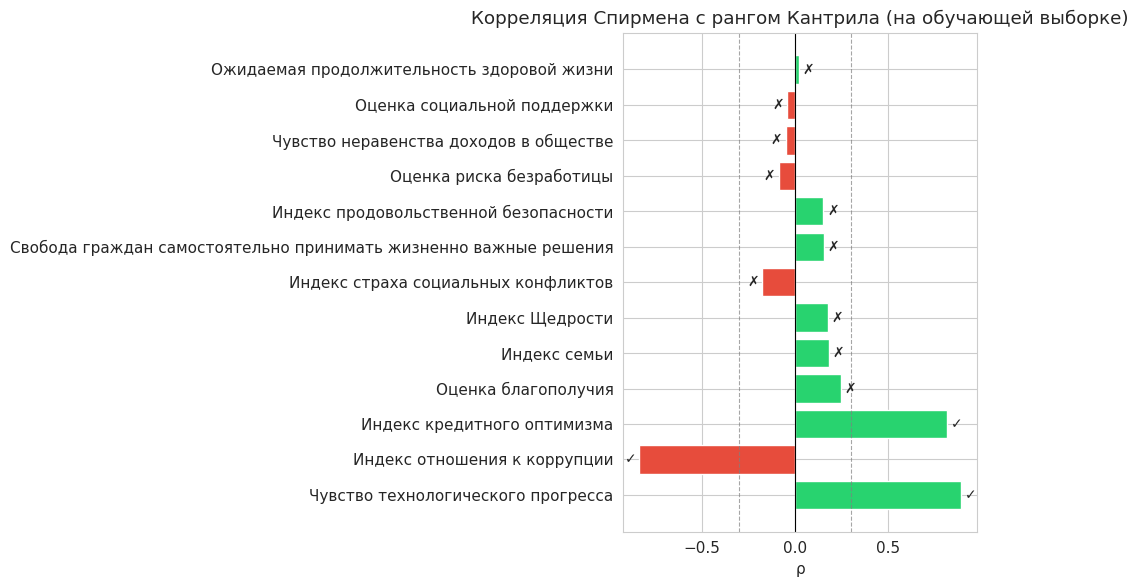

In [188]:
# 3. ВИЗУАЛИЗАЦИЯ
fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#28d36f" if r > 0 else "#e74c3c" for r in corr_df["Spearman"]]
ax.barh(corr_df["Признак состояния"], corr_df["Spearman"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)

# Рисуем пороги отсечения (пунктиром)
ax.axvline(
    RHO_THRESHOLD, color="gray", linestyle="--", linewidth=0.8, alpha=0.7
)
ax.axvline(
    -RHO_THRESHOLD, color="gray", linestyle="--", linewidth=0.8, alpha=0.7
)

for i, (_, row) in enumerate(corr_df.iterrows()):
    is_selected = (row["p-value"] < PVALUE_THRESHOLD) and (
        abs(row["Spearman"]) >= RHO_THRESHOLD
    )
    marker = "✓" if is_selected else "✗"
    if is_selected:
        print(row["Признак состояния"])
    x = row["Spearman"]
    ax.text(
        x + (0.02 if x >= 0 else -0.08), i, marker, va="center", fontsize=10
    )

ax.set_title("Корреляция Спирмена с рангом Кантрила (на обучающей выборке)")
ax.set_xlabel("ρ")
plt.tight_layout()
plt.show()


### 9. Построить модели прогноза признаков состояния по признакам причины

ПОСТРОЕНИЕ OLS ДЛЯ ОТОБРАННЫХ ПРИЗНАКОВ СОСТОЯНИЯ

Признак 'Чувство технологического прогресса'
  R²:               0.878
  Durbin-Watson:    1.963
  Бреуш-Паган p:    0.2524 → ОК
  SE:               обычные
  Шапиро-Уилк p:    0.4321 → нормальны


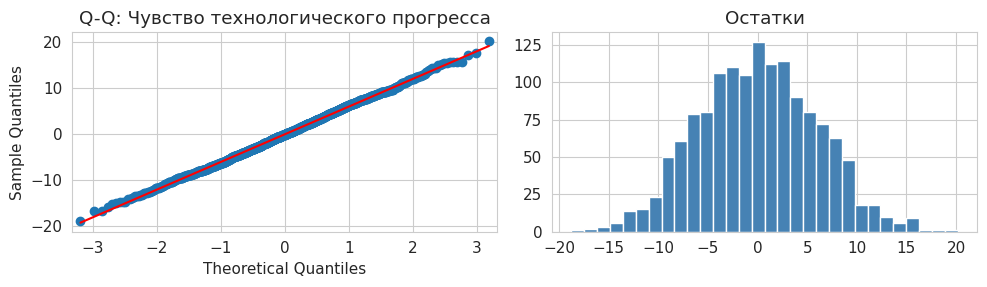


Признак 'Индекс отношения к коррупции'
  R²:               0.867
  Durbin-Watson:    1.924
  Бреуш-Паган p:    0.0555 → ОК
  SE:               обычные
  Шапиро-Уилк p:    0.7743 → нормальны


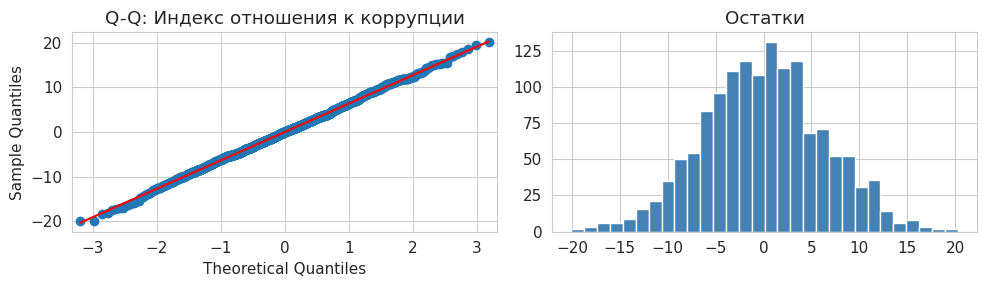


Признак 'Индекс кредитного оптимизма'
  R²:               0.554
  Durbin-Watson:    1.969
  Бреуш-Паган p:    0.5282 → ОК
  SE:               обычные
  Шапиро-Уилк p:    0.9476 → нормальны


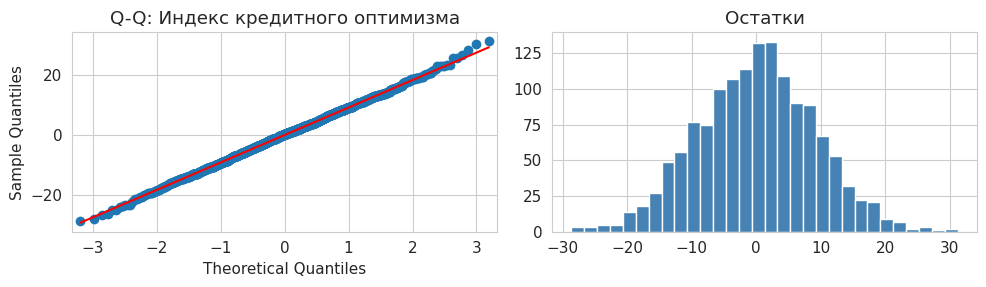


OLS-моделей обучено: 3


In [189]:
ols_models = {}
ols_predictions_train = pd.DataFrame(index=df_train.index)
ols_predictions_test = pd.DataFrame(index=df_test.index)
ols_predictions_unk = pd.DataFrame(index=df_unknown.index)

print("ПОСТРОЕНИЕ OLS ДЛЯ ОТОБРАННЫХ ПРИЗНАКОВ СОСТОЯНИЯ")

# Медианы причин считаем один раз по train
cause_medians = df_train[cause_cols].median()

for target_col in selected_state:
    print(f"\n{'=' * 55}")
    print(f"Признак '{target_col}'")
    print(f"{'=' * 55}")

    # Для обучения модели выкидываем NaN записи (OLS должна учиться на чистых фактах)
    y_ols = df_train[target_col].dropna()
    X_ols = df_train.loc[y_ols.index, cause_cols].dropna()
    y_ols = y_ols.loc[X_ols.index]

    if len(y_ols) < 20:
        print("Недостаточно данных, пропуск.")
        continue

    # Сначала OLS без коррекции — для теста Бреуша-Пагана
    model_ols = sm.OLS(y_ols, sm.add_constant(X_ols)).fit()
    _, p_bp, _, _ = sm.stats.diagnostic.het_breuschpagan(
        model_ols.resid, model_ols.model.exog
    )

    # ИСПРАВЛЕНИЕ: HC3 только при гетероскедастичности, иначе обычные SE
    if p_bp < 0.05:
        model = sm.OLS(y_ols, sm.add_constant(X_ols)).fit(cov_type="HC3")
        se_note = "HC3 (робастные)"
    else:
        model = model_ols
        se_note = "обычные"

    ols_models[target_col] = {"model": model, "features": cause_cols}

    dw = durbin_watson(model.resid)
    _, p_shapiro = shapiro(model.resid)

    # (норма 1.5–2.5) для DW
    print(f"  R²:               {model.rsquared:.3f}")
    print(f"  Durbin-Watson:    {dw:.3f}")
    print(f"  Бреуш-Паган p:    {p_bp:.4f} {'HC3' if p_bp < 0.05 else '→ ОК'}")
    print(f"  SE:               {se_note}")
    print(
        f"  Шапиро-Уилк p:    {p_shapiro:.4f} {'→ не нормальны' if p_shapiro < 0.05 else '→ нормальны'}"
    )

    # Q-Q plot
    fig, axes = plt.subplots(1, 2, figsize=(10, 3))
    sm.qqplot(model.resid, line="s", ax=axes[0])
    axes[0].set_title(f"Q-Q: {target_col[:40]}")
    axes[1].hist(model.resid, bins=30, color="steelblue", edgecolor="white")
    axes[1].set_title("Остатки")
    plt.tight_layout()
    plt.show()

    # Формируем предсказания для всех трёх частей
    for src_df, store in [
        (df_train, ols_predictions_train),
        (df_test, ols_predictions_test),
        (df_unknown, ols_predictions_unk),
    ]:
        # Заполняем пропуски в причинах медианами train перед прогнозом
        X_filled = src_df[cause_cols].fillna(cause_medians)
        Xp = sm.add_constant(X_filled, has_constant="add")
        store[target_col] = model.predict(Xp)

print(f"\nOLS-моделей обучено: {len(ols_models)}")

### 10. По наблюдениям с известным счастьем построить модель классификации счастья (логистическая / мультиномиальная логистическая регрессия)

Признаков для классификатора: 13
  Причинных (cause_cols):    10
  OLS-состояний:             3
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Лучший C: 0.5
Лучший class_weight: None
CV micro precision (train): 0.543

Модель: LogisticRegression (multinomial, GridSearchCV)
Micro Precision: 0.549  (критерий: > 0.6)
Критерий НЕ выполнен ✗

Classification Report:

              precision    recall  f1-score   support

           0       0.96      0.92      0.94        24
           1       0.59      0.54      0.57        35
           2       0.61      0.73      0.66        55
           3       0.39      0.46      0.42        54
           4       0.47      0.39      0.42        44
           5       0.46      0.47      0.46        45
           6       0.52      0.27      0.36        55
           7       0.46      0.52      0.49        56
           8       0.57      0.70      0.63        67
           9       0.76      0.65      0.70        40

    accuracy             

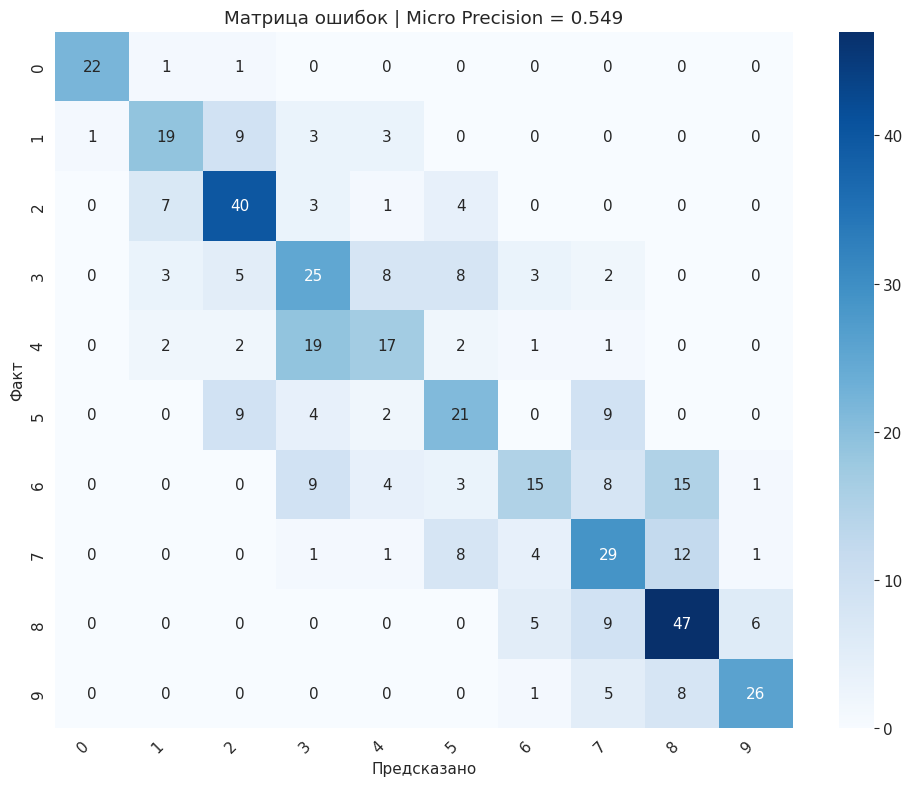

In [190]:
# Порог качества: состояние должно хорошо предсказываться по причинам
R2_THRESHOLD = 0.1

# Берем только те состояния, которые:
# 1) отобраны по связи со счастьем (selected_state)
# 2) имеют OLS-модель на train
# 3) имеют R^2 >= порога
final_states = [
    col
    for col in selected_state
    if col in ols_models and ols_models[col]["model"].rsquared >= R2_THRESHOLD
]

# Покажем, какие состояния отфильтрованы из-за низкого R^2
excluded_states = [
    col
    for col in selected_state
    if col in ols_models and ols_models[col]["model"].rsquared < R2_THRESHOLD
]
if excluded_states:
    print(f"Исключены по R² < {R2_THRESHOLD}:")
    for col in excluded_states:
        r2_val = ols_models[col]["model"].rsquared
        print(f"  • {col} (R²={r2_val:.3f})")

# Медианы OLS-предсказаний по train (для заполнения редких пропусков)
state_medians = ols_predictions_train[final_states].median()


def build_X(cause_df, ols_preds_df):
    """Признаки = причины + OLS-предсказания состояний (везде одинаково)."""
    X_c = cause_df[cause_cols].fillna(cause_medians)
    X_s = ols_preds_df[final_states].fillna(state_medians)
    return pd.concat(
        [X_c.reset_index(drop=True), X_s.reset_index(drop=True)], axis=1
    )


X_clf_train = build_X(df_train, ols_predictions_train)
X_clf_test = build_X(df_test, ols_predictions_test)
X_clf_unk = build_X(df_unknown, ols_predictions_unk)

print(f"Признаков для классификатора: {X_clf_train.shape[1]}")
print(f"  Причинных (cause_cols):    {len(cause_cols)}")
print(f"  OLS-состояний:             {len(final_states)}")

y_train_labels = y_train.values
y_test_labels = y_test.values

# GridSearchCV для подбора C и регуляризации
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

pipe = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        (
            "classifier",
            LogisticRegression(
                solver="lbfgs",
                class_weight=None,
                penalty="l2",
                max_iter=4000,
                random_state=42,
            ),
        ),
    ]
)

param_grid = {
    "classifier__C": [
        0.001,
        0.005,
        0.01,
        0.05,
        0.1,
        0.5,
        1.0,
        5.0,
        10.0,
        50.0,
    ],
    "classifier__class_weight": [None, "balanced"],
}

grid_search = GridSearchCV(
    pipe,
    param_grid,
    cv=cv,
    scoring="precision_micro",
    n_jobs=-1,
    verbose=1,
)
grid_search.fit(X_clf_train, y_train_labels)

print(f"\nЛучший C: {grid_search.best_params_['classifier__C']}")
print(
    f"Лучший class_weight: {grid_search.best_params_['classifier__class_weight']}"
)
print(f"CV micro precision (train): {grid_search.best_score_:.3f}")

clf_pipeline = grid_search.best_estimator_

y_pred_labels = clf_pipeline.predict(X_clf_test)

all_label_classes = sorted(list(set(y_test_labels) | set(y_pred_labels)))
micro_prec = precision_score(
    y_test_labels,
    y_pred_labels,
    average="micro",
    labels=all_label_classes,
)
print("\nМодель: LogisticRegression (multinomial, GridSearchCV)")
print(f"Micro Precision: {micro_prec:.3f}  (критерий: > 0.6)")
print("Критерий", "ВЫПОЛНЕН ✓" if micro_prec > 0.6 else "НЕ выполнен ✗")

actual_test_classes = sorted(list(set(y_test_labels)))
print("\nClassification Report:\n")
print(
    classification_report(
        y_test_labels,
        y_pred_labels,
        labels=actual_test_classes,
        zero_division=0,
    )
)

cm = confusion_matrix(y_test_labels, y_pred_labels, labels=actual_test_classes)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=actual_test_classes,
    yticklabels=actual_test_classes,
    ax=ax,
)
ax.set_xlabel("Предсказано")
ax.set_ylabel("Факт")
ax.set_title(f"Матрица ошибок | Micro Precision = {micro_prec:.3f}")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### 12. Спрогнозировать неизвестные значения счастья

In [191]:
df_unknown_predicted = df_unknown.copy()

# Передаем данные в pipeline (он сам масштабирует)
df_unknown_predicted["Predicted_Happiness"] = clf_pipeline.predict(X_clf_unk)

# Обратно декодируем числа классов в текстовые метки
rank_to_class = {i: cls for i, cls in enumerate(actual_classes)}
df_unknown_predicted["Predicted_Class"] = df_unknown_predicted[
    "Predicted_Happiness"
].map(rank_to_class)

# Предсказываем вероятности
probs = clf_pipeline.predict_proba(X_clf_unk)

# Добавляем вероятности в датафрейм
for i, class_idx in enumerate(clf_pipeline.named_steps["classifier"].classes_):
    class_name = rank_to_class.get(class_idx, f"Class_{class_idx}")
    df_unknown_predicted[f"Prob_{class_name}"] = np.round(probs[:, i], 3)

print("--- Распределение предсказанных групп ---")
print(df_unknown_predicted["Predicted_Class"].value_counts(dropna=False))

print("\n--- Первые 5 строк с прогнозами ---")
prob_cols = [
    col for col in df_unknown_predicted.columns if col.startswith("Prob_")
]
cols_to_show = [CANTRIL_COL, "Predicted_Class"] + prob_cols

display(df_unknown_predicted[cols_to_show].head())

--- Распределение предсказанных групп ---
Predicted_Class
Thriving      92
Suffering     88
Strugglng     77
Blooming      77
Doing well    59
Prospering    53
Just ok       52
Coping        44
Depressed     33
Hopeless      25
Name: count, dtype: int64

--- Первые 5 строк с прогнозами ---


,Ощущаемое счастье,Predicted_Class,Prob_Hopeless,Prob_Depressed,Prob_Suffering,Prob_Strugglng,Prob_Coping,Prob_Just ok,Prob_Doing well,Prob_Blooming,Prob_Thriving,Prob_Prospering
4,Неизвестно,Coping,0.000,0.017,0.038,0.295,0.341,0.205,0.066,0.036,0.001,0.0
8,Неизвестно,Depressed,0.155,0.444,0.391,0.006,0.003,0.000,0.000,0.000,0.000,0.0
20,Неизвестно,Strugglng,0.000,0.004,0.006,0.291,0.271,0.026,0.272,0.123,0.007,0.0
25,Неизвестно,Strugglng,0.000,0.016,0.026,0.484,0.308,0.085,0.065,0.017,0.000,0.0
36,Неизвестно,Doing well,0.000,0.002,0.005,0.210,0.257,0.057,0.260,0.199,0.010,0.0
